In [1]:
from google.colab import files
uploaded = files.upload()



Saving Labeled_Social_NLP_Training_Data.csv to Labeled_Social_NLP_Training_Data (1).csv


DATASET OVERVIEW
Shape: (9000, 4)

Columns:
['text_id', 'post_text', 'sentiment_label', 'topic_category']

Data Types:
text_id            object
post_text          object
sentiment_label    object
topic_category     object
dtype: object

First 5 rows:


,text_id,post_text,sentiment_label,topic_category
0,TXT_00001,some1 come wait in line with me Thursday at 3@...,Negative,Community_Discussion
1,TXT_00002,Mancity strikers Aguero and Dzeko you better t...,Positive,Community_Discussion
2,TXT_00003,Would you like to join us at our annual gala a...,Positive,Community_Discussion
3,TXT_00004,"""Sicily may form grand coalition, Italian UDC ...",Neutral,Community_Discussion
4,TXT_00005,@user @user If the comment was in reference to...,Negative,Community_Discussion



Missing Values:
text_id            0
post_text          0
sentiment_label    0
topic_category     0
dtype: int64

Duplicate Rows:
0

Unique Values:
text_id: 9000
post_text: 7900
sentiment_label: 3
topic_category: 4

SENTIMENT DISTRIBUTION
sentiment_label
Negative    3000
Positive    3000
Neutral     3000
Name: count, dtype: int64

Percentage:
sentiment_label
Negative    33.33
Positive    33.33
Neutral     33.33
Name: count, dtype: float64


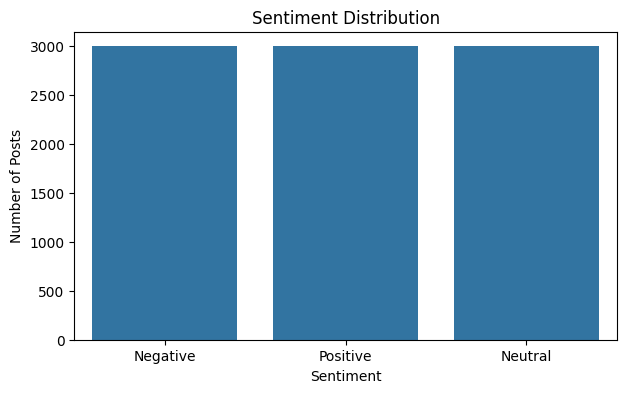


TOPIC DISTRIBUTION
topic_category
Community_Discussion    7752
Technical_Issues         815
Feature_Feedback         297
Account_Security         136
Name: count, dtype: int64

Percentage:
topic_category
Community_Discussion    86.13
Technical_Issues         9.06
Feature_Feedback         3.30
Account_Security         1.51
Name: count, dtype: float64


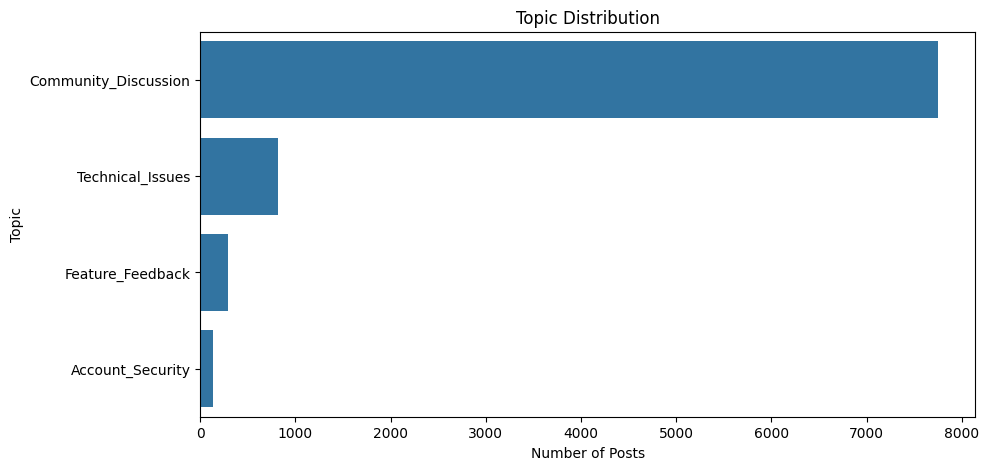


TEXT LENGTH STATISTICS
        word_count   char_count
count  9000.000000  9000.000000
mean     19.472111   107.985778
std       4.933866    26.104963
min       4.000000    25.000000
25%      16.000000    91.000000
50%      20.000000   113.000000
75%      23.000000   129.000000
max      35.000000   180.000000


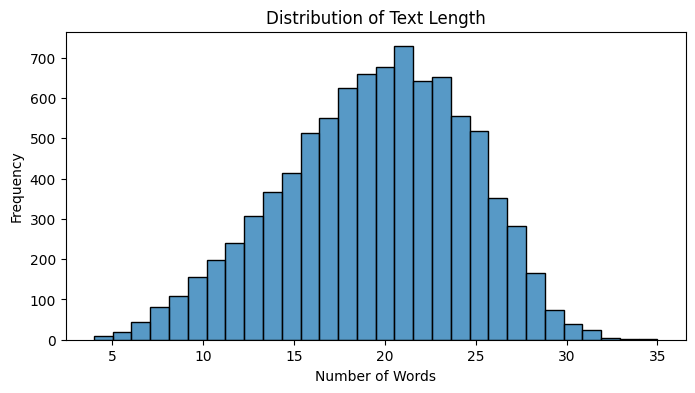


DUPLICATE TEXT ANALYSIS
Duplicate text rows: 1100
Unique texts: 7900

Texts appearing more than once:
987

Top repeated texts:


,frequency,count
0,I may have just dropped two letter grades of i...,5
1,Also just now starting Miss USA so nobody text...,4
2,When you feel like Zayn is going to follow you...,4
3,@user no live NBA game tomorrow? only postgame...,4
4,John Kasich may end up blowing by Jeb Bush bef...,4
5,"""De La Soul were disappointing. Lazy &amp; uni...",4
6,TFI Friday and Chris Evans need to fuck off ba...,4
7,Might be getting a little excited about seeing...,4
8,"""Tracy McGrady signed with a team in China tod...",4
9,Its November already.. Christmas will be here ...,4



Duplicate texts with different labels:


,occurrences,unique_sentiments,unique_topics
post_text,,,



SENTIMENT × TOPIC


sentiment_label,Negative,Neutral,Positive
topic_category,,,
Account_Security,34,47,55
Community_Discussion,2583,2623,2546
Feature_Feedback,119,104,74
Technical_Issues,264,226,325


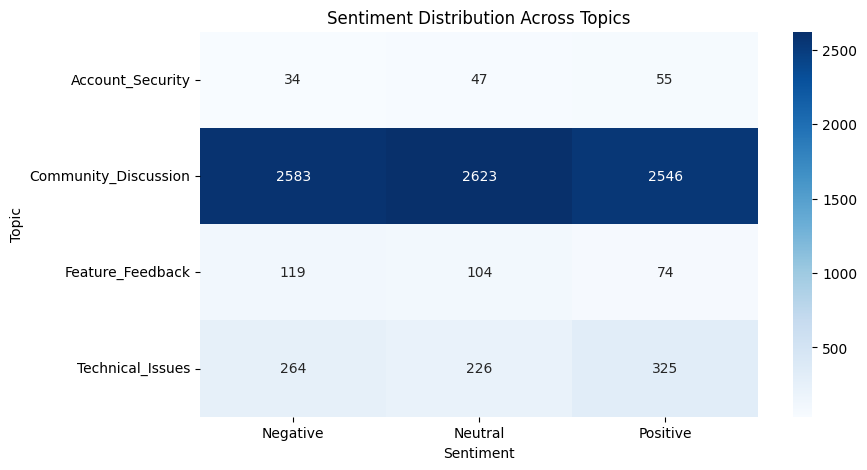

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Labeled_Social_NLP_Training_Data.csv")

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nUnique Values:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

# ---------------------------------------------------------
# SENTIMENT DISTRIBUTION
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("SENTIMENT DISTRIBUTION")
print("=" * 60)

sentiment_counts = df["sentiment_label"].value_counts()

print(sentiment_counts)
print("\nPercentage:")
print((sentiment_counts / len(df) * 100).round(2))

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="sentiment_label")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Posts")
plt.show()

# ---------------------------------------------------------
# TOPIC DISTRIBUTION
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("TOPIC DISTRIBUTION")
print("=" * 60)

topic_counts = df["topic_category"].value_counts()

print(topic_counts)
print("\nPercentage:")
print((topic_counts / len(df) * 100).round(2))

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    y="topic_category",
    order=topic_counts.index
)
plt.title("Topic Distribution")
plt.xlabel("Number of Posts")
plt.ylabel("Topic")
plt.show()

# ---------------------------------------------------------
# TEXT LENGTH
# ---------------------------------------------------------

df["word_count"] = df["post_text"].astype(str).str.split().str.len()
df["char_count"] = df["post_text"].astype(str).str.len()

print("\n" + "=" * 60)
print("TEXT LENGTH STATISTICS")
print("=" * 60)

print(df[["word_count", "char_count"]].describe())

plt.figure(figsize=(8, 4))
sns.histplot(df["word_count"], bins=30)
plt.title("Distribution of Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

# ---------------------------------------------------------
# DUPLICATE TEXT ANALYSIS
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("DUPLICATE TEXT ANALYSIS")
print("=" * 60)

duplicate_text_count = df["post_text"].duplicated().sum()

print("Duplicate text rows:", duplicate_text_count)
print("Unique texts:", df["post_text"].nunique())

# How many texts occur more than once?
text_frequency = df["post_text"].value_counts()

print("\nTexts appearing more than once:")
print((text_frequency > 1).sum())

print("\nTop repeated texts:")
display(
    text_frequency[text_frequency > 1]
    .head(10)
    .reset_index()
    .rename(columns={
        "index": "post_text",
        "post_text": "frequency"
    })
)

# ---------------------------------------------------------
# DUPLICATES ACROSS LABELS
# ---------------------------------------------------------

duplicate_texts = (
    df.groupby("post_text")
      .agg(
          occurrences=("post_text", "size"),
          unique_sentiments=("sentiment_label", "nunique"),
          unique_topics=("topic_category", "nunique")
      )
      .query("occurrences > 1")
      .sort_values("occurrences", ascending=False)
)

print("\nDuplicate texts with different labels:")
display(
    duplicate_texts[
        (duplicate_texts["unique_sentiments"] > 1) |
        (duplicate_texts["unique_topics"] > 1)
    ].head(20)
)

# ---------------------------------------------------------
# SENTIMENT × TOPIC
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("SENTIMENT × TOPIC")
print("=" * 60)

cross_tab = pd.crosstab(
    df["topic_category"],
    df["sentiment_label"]
)

display(cross_tab)

plt.figure(figsize=(9, 5))
sns.heatmap(cross_tab, annot=True, fmt="d", cmap="Blues")
plt.title("Sentiment Distribution Across Topics")
plt.xlabel("Sentiment")
plt.ylabel("Topic")
plt.show()

In [3]:
from sklearn.model_selection import StratifiedGroupKFold

# ---------------------------------------------------------
# PREPARE DATA
# ---------------------------------------------------------

data = df[[
    "text_id",
    "post_text",
    "sentiment_label",
    "topic_category"
]].copy()

# Combined label for stratification
data["stratify_label"] = (
    data["sentiment_label"] + "_" + data["topic_category"]
)

print("Dataset shape:", data.shape)

# ---------------------------------------------------------
# STRATIFIED GROUP SPLIT
# ---------------------------------------------------------

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# First fold = test set
train_idx, test_idx = next(
    sgkf.split(
        data,
        y=data["stratify_label"],
        groups=data["post_text"]
    )
)

train_df = data.iloc[train_idx].copy()
test_df = data.iloc[test_idx].copy()

train_df.drop(columns=["stratify_label"], inplace=True)
test_df.drop(columns=["stratify_label"], inplace=True)

# ---------------------------------------------------------
# BASIC SPLIT INFORMATION
# ---------------------------------------------------------

print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

print(
    "Training percentage:",
    round(len(train_df) / len(data) * 100, 2), "%"
)

print(
    "Testing percentage:",
    round(len(test_df) / len(data) * 100, 2), "%"
)

# ---------------------------------------------------------
# CHECK TEXT LEAKAGE
# ---------------------------------------------------------

train_texts = set(train_df["post_text"])
test_texts = set(test_df["post_text"])

overlap = train_texts.intersection(test_texts)

print("\n" + "=" * 60)
print("DATA LEAKAGE CHECK")
print("=" * 60)

print("Unique training texts:", len(train_texts))
print("Unique testing texts:", len(test_texts))
print("Text overlap:", len(overlap))

# ---------------------------------------------------------
# SENTIMENT DISTRIBUTION
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("SENTIMENT DISTRIBUTION")
print("=" * 60)

print("\nTRAIN:")
print(train_df["sentiment_label"].value_counts())

print("\nTEST:")
print(test_df["sentiment_label"].value_counts())

print("\nTRAIN (%):")
print(
    (train_df["sentiment_label"]
     .value_counts(normalize=True) * 100).round(2)
)

print("\nTEST (%):")
print(
    (test_df["sentiment_label"]
     .value_counts(normalize=True) * 100).round(2)
)

# ---------------------------------------------------------
# TOPIC DISTRIBUTION
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("TOPIC DISTRIBUTION")
print("=" * 60)

print("\nTRAIN:")
print(train_df["topic_category"].value_counts())

print("\nTEST:")
print(test_df["topic_category"].value_counts())

print("\nTRAIN (%):")
print(
    (train_df["topic_category"]
     .value_counts(normalize=True) * 100).round(2)
)

print("\nTEST (%):")
print(
    (test_df["topic_category"]
     .value_counts(normalize=True) * 100).round(2)
)

# ---------------------------------------------------------
# SENTIMENT × TOPIC
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("TRAIN: SENTIMENT × TOPIC")
print("=" * 60)

display(
    pd.crosstab(
        train_df["topic_category"],
        train_df["sentiment_label"]
    )
)

print("\n" + "=" * 60)
print("TEST: SENTIMENT × TOPIC")
print("=" * 60)

display(
    pd.crosstab(
        test_df["topic_category"],
        test_df["sentiment_label"]
    )
)

Dataset shape: (9000, 5)
TRAIN / TEST SPLIT
Training rows: 7183
Testing rows: 1817
Training percentage: 79.81 %
Testing percentage: 20.19 %

DATA LEAKAGE CHECK
Unique training texts: 6320
Unique testing texts: 1580
Text overlap: 0

SENTIMENT DISTRIBUTION

TRAIN:
sentiment_label
Neutral     2420
Positive    2415
Negative    2348
Name: count, dtype: int64

TEST:
sentiment_label
Negative    652
Positive    585
Neutral     580
Name: count, dtype: int64

TRAIN (%):
sentiment_label
Neutral     33.69
Positive    33.62
Negative    32.69
Name: proportion, dtype: float64

TEST (%):
sentiment_label
Negative    35.88
Positive    32.20
Neutral     31.92
Name: proportion, dtype: float64

TOPIC DISTRIBUTION

TRAIN:
topic_category
Community_Discussion    6203
Technical_Issues         637
Feature_Feedback         232
Account_Security         111
Name: count, dtype: int64

TEST:
topic_category
Community_Discussion    1549
Technical_Issues         178
Feature_Feedback          65
Account_Security        

sentiment_label,Negative,Neutral,Positive
topic_category,,,
Account_Security,29,38,44
Community_Discussion,2022,2130,2051
Feature_Feedback,91,82,59
Technical_Issues,206,170,261



TEST: SENTIMENT × TOPIC


sentiment_label,Negative,Neutral,Positive
topic_category,,,
Account_Security,5,9,11
Community_Discussion,561,493,495
Feature_Feedback,28,22,15
Technical_Issues,58,56,64


In [4]:
# =========================================================
# STEP 3 — TEXT PREPROCESSING + TF-IDF
# =========================================================

import re
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer

# ---------------------------------------------------------
# BASIC TEXT PREPROCESSING
# ---------------------------------------------------------

def clean_text(text):
    """
    Lightweight preprocessing for social-media text.
    We intentionally avoid aggressive stopword removal.
    """

    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Replace user mentions with a common token
    text = re.sub(r"@\w+", " USERMENTION ", text)

    # Replace multiple spaces
    text = re.sub(r"\s+", " ", text)

    # Remove leading/trailing spaces
    text = text.strip()

    return text


# Apply preprocessing
train_text = train_df["post_text"].apply(clean_text)
test_text = test_df["post_text"].apply(clean_text)

print("=" * 60)
print("TEXT PREPROCESSING")
print("=" * 60)

print("Training documents:", len(train_text))
print("Testing documents:", len(test_text))

print("\nExample:")
print("Original:")
print(train_df["post_text"].iloc[0])

print("\nCleaned:")
print(train_text.iloc[0])


# ---------------------------------------------------------
# TF-IDF VECTORIZER
# ---------------------------------------------------------

tfidf = TfidfVectorizer(
    lowercase=False,        # already converted to lowercase
    ngram_range=(1, 2),     # unigrams + bigrams
    min_df=2,               # ignore terms appearing only once
    max_df=0.95,            # ignore extremely common terms
    sublinear_tf=True
)

# IMPORTANT:
# Fit ONLY on training data
X_train = tfidf.fit_transform(train_text)

# Transform test data using the already fitted vectorizer
X_test = tfidf.transform(test_text)


# ---------------------------------------------------------
# INFORMATION
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("TF-IDF FEATURES")
print("=" * 60)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("Number of TF-IDF features:", len(tfidf.get_feature_names_out()))

print("\nSample features:")
print(tfidf.get_feature_names_out()[:30])

# ---------------------------------------------------------
# LABELS
# ---------------------------------------------------------

y_sentiment_train = train_df["sentiment_label"]
y_sentiment_test = test_df["sentiment_label"]

y_topic_train = train_df["topic_category"]
y_topic_test = test_df["topic_category"]

print("\n" + "=" * 60)
print("LABELS")
print("=" * 60)

print("\nSentiment classes:")
print(sorted(y_sentiment_train.unique()))

print("\nTopic classes:")
print(sorted(y_topic_train.unique()))

print("\nTF-IDF preprocessing completed successfully.")

TEXT PREPROCESSING
Training documents: 7183
Testing documents: 1817

Example:
Original:
some1 come wait in line with me Thursday at 3@target bc briana is being a bitch

Cleaned:
some1 come wait in line with me thursday at 3 USERMENTION bc briana is being a bitch

TF-IDF FEATURES
X_train shape: (7183, 25641)
X_test shape: (1817, 25641)
Number of TF-IDF features: 25641

Sample features:
['00' '00 can' '00 pm' '00 pure' '000' '000 jerry' '000 students'
 '000 tons' '007' '00am' '00pm' '01' '01 26' '04' '05' '05 beat' '05 on'
 '07' '08' '10' '10 2012' '10 27' '10 30' '10 30am' '10 45' '10 cr'
 '10 est' '10 feet' '10 for' '10 hours']

LABELS

Sentiment classes:
['Negative', 'Neutral', 'Positive']

Topic classes:
['Account_Security', 'Community_Discussion', 'Feature_Feedback', 'Technical_Issues']

TF-IDF preprocessing completed successfully.


In [5]:
# =========================================================
# STEP 4 — BASELINE NLP MODELS
# =========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# ---------------------------------------------------------
# FUNCTION TO EVALUATE MODEL
# ---------------------------------------------------------

def evaluate_model(model, X_train, y_train, X_test, y_test, name):

    # Train
    model.fit(X_train, y_train)

    # Predict
    predictions = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print(f"Accuracy       : {accuracy:.4f}")
    print(f"Macro Precision: {precision:.4f}")
    print(f"Macro Recall   : {recall:.4f}")
    print(f"Macro F1       : {macro_f1:.4f}")
    print(f"Weighted F1    : {weighted_f1:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            predictions,
            zero_division=0
        )
    )

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
        "model_object": model,
        "predictions": predictions
    }


# =========================================================
# SENTIMENT MODELS
# =========================================================

print("\n\n")
print("#" * 70)
print("SENTIMENT CLASSIFICATION")
print("#" * 70)

sentiment_results = []

# Logistic Regression
sentiment_lr = LogisticRegression(
    max_iter=2000,
    random_state=42
)

result = evaluate_model(
    sentiment_lr,
    X_train,
    y_sentiment_train,
    X_test,
    y_sentiment_test,
    "Sentiment - Logistic Regression"
)

sentiment_results.append(result)


# Linear SVM
sentiment_svm = LinearSVC(
    random_state=42
)

result = evaluate_model(
    sentiment_svm,
    X_train,
    y_sentiment_train,
    X_test,
    y_sentiment_test,
    "Sentiment - Linear SVM"
)

sentiment_results.append(result)


# =========================================================
# TOPIC MODELS
# =========================================================

print("\n\n")
print("#" * 70)
print("TOPIC CLASSIFICATION")
print("#" * 70)

topic_results = []

# Logistic Regression
topic_lr = LogisticRegression(
    max_iter=2000,
    random_state=42
)

result = evaluate_model(
    topic_lr,
    X_train,
    y_topic_train,
    X_test,
    y_topic_test,
    "Topic - Logistic Regression"
)

topic_results.append(result)


# Linear SVM
topic_svm = LinearSVC(
    random_state=42
)

result = evaluate_model(
    topic_svm,
    X_train,
    y_topic_train,
    X_test,
    y_topic_test,
    "Topic - Linear SVM"
)

topic_results.append(result)


# =========================================================
# MODEL COMPARISON
# =========================================================

sentiment_comparison = pd.DataFrame([
    {
        "Model": r["Model"],
        "Accuracy": r["Accuracy"],
        "Macro Precision": r["Macro Precision"],
        "Macro Recall": r["Macro Recall"],
        "Macro F1": r["Macro F1"],
        "Weighted F1": r["Weighted F1"]
    }
    for r in sentiment_results
])

topic_comparison = pd.DataFrame([
    {
        "Model": r["Model"],
        "Accuracy": r["Accuracy"],
        "Macro Precision": r["Macro Precision"],
        "Macro Recall": r["Macro Recall"],
        "Macro F1": r["Macro F1"],
        "Weighted F1": r["Weighted F1"]
    }
    for r in topic_results
])


print("\n" + "=" * 70)
print("SENTIMENT MODEL COMPARISON")
print("=" * 70)

display(
    sentiment_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Weighted F1": "{:.4f}"
    })
)


print("\n" + "=" * 70)
print("TOPIC MODEL COMPARISON")
print("=" * 70)

display(
    topic_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Weighted F1": "{:.4f}"
    })
)




######################################################################
SENTIMENT CLASSIFICATION
######################################################################

Sentiment - Logistic Regression
Accuracy       : 0.5971
Macro Precision: 0.5991
Macro Recall   : 0.5967
Macro F1       : 0.5971
Weighted F1    : 0.5987

Classification Report:
              precision    recall  f1-score   support

    Negative       0.66      0.60      0.63       652
     Neutral       0.50      0.54      0.52       580
    Positive       0.63      0.64      0.64       585

    accuracy                           0.60      1817
   macro avg       0.60      0.60      0.60      1817
weighted avg       0.60      0.60      0.60      1817


Sentiment - Linear SVM
Accuracy       : 0.5927
Macro Precision: 0.5931
Macro Recall   : 0.5925
Macro F1       : 0.5919
Weighted F1    : 0.5934

Classification Report:
              precision    recall  f1-score   support

    Negative       0.66      0.60      0.63      

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Sentiment - Logistic Regression,0.5971,0.5991,0.5967,0.5971,0.5987
1,Sentiment - Linear SVM,0.5927,0.5931,0.5925,0.5919,0.5934



TOPIC MODEL COMPARISON


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Topic - Logistic Regression,0.8795,0.4690,0.3188,0.3414,0.8385
1,Topic - Linear SVM,0.9141,0.8939,0.4736,0.5465,0.8920


In [6]:
# =========================================================
# STEP 5 — CLASS IMBALANCE HANDLING
# =========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# ---------------------------------------------------------
# EVALUATION FUNCTION
# ---------------------------------------------------------

def evaluate_weighted_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    name
):

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    macro_precision = precision_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print(f"Accuracy       : {accuracy:.4f}")
    print(f"Macro Precision: {macro_precision:.4f}")
    print(f"Macro Recall   : {macro_recall:.4f}")
    print(f"Macro F1       : {macro_f1:.4f}")
    print(f"Weighted F1    : {weighted_f1:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            predictions,
            zero_division=0
        )
    )

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
        "model_object": model,
        "predictions": predictions
    }


# =========================================================
# SENTIMENT — CLASS WEIGHTED
# =========================================================

print("\n" + "#" * 70)
print("SENTIMENT — CLASS WEIGHTED")
print("#" * 70)

weighted_sentiment_results = []

# Logistic Regression
sentiment_lr_balanced = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

result = evaluate_weighted_model(
    sentiment_lr_balanced,
    X_train,
    y_sentiment_train,
    X_test,
    y_sentiment_test,
    "Sentiment - Logistic Regression (Balanced)"
)

weighted_sentiment_results.append(result)


# Linear SVM
sentiment_svm_balanced = LinearSVC(
    class_weight="balanced",
    random_state=42
)

result = evaluate_weighted_model(
    sentiment_svm_balanced,
    X_train,
    y_sentiment_train,
    X_test,
    y_sentiment_test,
    "Sentiment - Linear SVM (Balanced)"
)

weighted_sentiment_results.append(result)


# =========================================================
# TOPIC — CLASS WEIGHTED
# =========================================================

print("\n" + "#" * 70)
print("TOPIC — CLASS WEIGHTED")
print("#" * 70)

weighted_topic_results = []

# Logistic Regression
topic_lr_balanced = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

result = evaluate_weighted_model(
    topic_lr_balanced,
    X_train,
    y_topic_train,
    X_test,
    y_topic_test,
    "Topic - Logistic Regression (Balanced)"
)

weighted_topic_results.append(result)


# Linear SVM
topic_svm_balanced = LinearSVC(
    class_weight="balanced",
    random_state=42
)

result = evaluate_weighted_model(
    topic_svm_balanced,
    X_train,
    y_topic_train,
    X_test,
    y_topic_test,
    "Topic - Linear SVM (Balanced)"
)

weighted_topic_results.append(result)


# =========================================================
# COMPARISON TABLES
# =========================================================

def make_comparison(results):

    return pd.DataFrame([
        {
            "Model": r["Model"],
            "Accuracy": r["Accuracy"],
            "Macro Precision": r["Macro Precision"],
            "Macro Recall": r["Macro Recall"],
            "Macro F1": r["Macro F1"],
            "Weighted F1": r["Weighted F1"]
        }
        for r in results
    ])


print("\n" + "=" * 70)
print("BALANCED SENTIMENT MODELS")
print("=" * 70)

display(
    make_comparison(
        weighted_sentiment_results
    ).style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Weighted F1": "{:.4f}"
    })
)


print("\n" + "=" * 70)
print("BALANCED TOPIC MODELS")
print("=" * 70)

display(
    make_comparison(
        weighted_topic_results
    ).style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Weighted F1": "{:.4f}"
    })
)


######################################################################
SENTIMENT — CLASS WEIGHTED
######################################################################

Sentiment - Logistic Regression (Balanced)
Accuracy       : 0.5999
Macro Precision: 0.6003
Macro Recall   : 0.5990
Macro F1       : 0.5993
Weighted F1    : 0.6009

Classification Report:
              precision    recall  f1-score   support

    Negative       0.66      0.62      0.64       652
     Neutral       0.51      0.54      0.52       580
    Positive       0.63      0.64      0.64       585

    accuracy                           0.60      1817
   macro avg       0.60      0.60      0.60      1817
weighted avg       0.60      0.60      0.60      1817


Sentiment - Linear SVM (Balanced)
Accuracy       : 0.5916
Macro Precision: 0.5920
Macro Recall   : 0.5913
Macro F1       : 0.5908
Weighted F1    : 0.5923

Classification Report:
              precision    recall  f1-score   support

    Negative       0.66    

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Sentiment - Logistic Regression (Balanced),0.5999,0.6003,0.5990,0.5993,0.6009
1,Sentiment - Linear SVM (Balanced),0.5916,0.5920,0.5913,0.5908,0.5923



BALANCED TOPIC MODELS


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Topic - Logistic Regression (Balanced),0.9136,0.7858,0.5202,0.5985,0.9003
1,Topic - Linear SVM (Balanced),0.9191,0.9243,0.4997,0.5783,0.8994


In [7]:
# =========================================================
# STEP 6 — WORD + CHARACTER TF-IDF
# =========================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# ---------------------------------------------------------
# WORD TF-IDF
# ---------------------------------------------------------

word_tfidf = TfidfVectorizer(
    lowercase=False,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_word = word_tfidf.fit_transform(train_text)
X_test_word = word_tfidf.transform(test_text)

print("Word TF-IDF:")
print("Train:", X_train_word.shape)
print("Test :", X_test_word.shape)


# ---------------------------------------------------------
# CHARACTER TF-IDF
# ---------------------------------------------------------

char_tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2,
    max_features=30000,
    sublinear_tf=True
)

X_train_char = char_tfidf.fit_transform(train_text)
X_test_char = char_tfidf.transform(test_text)

print("\nCharacter TF-IDF:")
print("Train:", X_train_char.shape)
print("Test :", X_test_char.shape)


# ---------------------------------------------------------
# COMBINE WORD + CHARACTER FEATURES
# ---------------------------------------------------------

X_train_combined = hstack([
    X_train_word,
    X_train_char
])

X_test_combined = hstack([
    X_test_word,
    X_test_char
])

print("\nCombined TF-IDF:")
print("Train:", X_train_combined.shape)
print("Test :", X_test_combined.shape)

print("\nTotal features:",
      X_train_combined.shape[1])

Word TF-IDF:
Train: (7183, 25641)
Test : (1817, 25641)

Character TF-IDF:
Train: (7183, 30000)
Test : (1817, 30000)

Combined TF-IDF:
Train: (7183, 55641)
Test : (1817, 55641)

Total features: 55641


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# =========================
# SENTIMENT
# =========================

lr_sent_combined = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

lr_sent_combined.fit(
    X_train_combined,
    train_df["sentiment_label"]
)

pred_lr_sent = lr_sent_combined.predict(X_test_combined)

print("===== SENTIMENT: BALANCED LOGISTIC REGRESSION =====")
print("Accuracy :", accuracy_score(test_df["sentiment_label"], pred_lr_sent))
print("Macro F1 :", f1_score(
    test_df["sentiment_label"],
    pred_lr_sent,
    average="macro"
))

print(classification_report(
    test_df["sentiment_label"],
    pred_lr_sent
))


# =========================
# TOPIC
# =========================

lr_topic_combined = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

lr_topic_combined.fit(
    X_train_combined,
    train_df["topic_category"]
)

pred_lr_topic = lr_topic_combined.predict(X_test_combined)

print("===== TOPIC: BALANCED LOGISTIC REGRESSION =====")
print("Accuracy :", accuracy_score(test_df["topic_category"], pred_lr_topic))
print("Macro F1 :", f1_score(
    test_df["topic_category"],
    pred_lr_topic,
    average="macro"
))

print(classification_report(
    test_df["topic_category"],
    pred_lr_topic
))

===== SENTIMENT: BALANCED LOGISTIC REGRESSION =====
Accuracy : 0.6114474408365438
Macro F1 : 0.6120809365044231
              precision    recall  f1-score   support

    Negative       0.69      0.63      0.66       652
     Neutral       0.51      0.58      0.54       580
    Positive       0.65      0.63      0.64       585

    accuracy                           0.61      1817
   macro avg       0.62      0.61      0.61      1817
weighted avg       0.62      0.61      0.61      1817



In [ ]:
# =========================
# SENTIMENT - BALANCED SVM
# =========================

svm_sent_combined = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_sent_combined.fit(
    X_train_combined,
    train_df["sentiment_label"]
)

pred_svm_sent = svm_sent_combined.predict(X_test_combined)

print("===== SENTIMENT: BALANCED LINEAR SVM =====")
print("Accuracy :", accuracy_score(
    test_df["sentiment_label"],
    pred_svm_sent
))

print("Macro F1 :", f1_score(
    test_df["sentiment_label"],
    pred_svm_sent,
    average="macro"
))

print(classification_report(
    test_df["sentiment_label"],
    pred_svm_sent
))


# =========================
# TOPIC - BALANCED SVM
# =========================

svm_topic_combined = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_topic_combined.fit(
    X_train_combined,
    train_df["topic_category"]
)

pred_svm_topic = svm_topic_combined.predict(X_test_combined)

print("===== TOPIC: BALANCED LINEAR SVM =====")
print("Accuracy :", accuracy_score(
    test_df["topic_category"],
    pred_svm_topic
))

print("Macro F1 :", f1_score(
    test_df["topic_category"],
    pred_svm_topic,
    average="macro"
))

print(classification_report(
    test_df["topic_category"],
    pred_svm_topic
))

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Custom weights for topic classification
custom_weights = {
    "Account_Security": 3.0,
    "Community_Discussion": 1.0,
    "Feature_Feedback": 3.0,
    "Technical_Issues": 1.5
}

lr_topic_weighted = LogisticRegression(
    class_weight=custom_weights,
    max_iter=2000,
    random_state=42
)

lr_topic_weighted.fit(
    X_train_combined,
    train_df["topic_category"]
)

pred_topic_weighted = lr_topic_weighted.predict(X_test_combined)

print("===== TOPIC: CUSTOM CLASS-WEIGHTED LR =====")

print("Accuracy :",
      accuracy_score(
          test_df["topic_category"],
          pred_topic_weighted
      ))

print("Macro F1 :",
      f1_score(
          test_df["topic_category"],
          pred_topic_weighted,
          average="macro"
      ))

print(classification_report(
    test_df["topic_category"],
    pred_topic_weighted
))

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# =========================
# SENTIMENT CONFUSION MATRIX
# =========================

plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    test_df["sentiment_label"],
    pred_lr_sent,
    cmap="Blues",
    values_format="d"
)

plt.title("Sentiment Classification - Confusion Matrix")
plt.show()


# =========================
# TOPIC CONFUSION MATRIX
# =========================

plt.figure(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    test_df["topic_category"],
    pred_lr_topic,
    cmap="Blues",
    values_format="d"
)

plt.title("Topic Classification - Confusion Matrix")
plt.show()

In [ ]:
# ==========================================
# SENTIMENT ERROR ANALYSIS
# ==========================================

sentiment_errors = test_df[
    test_df["sentiment_label"] != pred_lr_sent
].copy()

sentiment_errors["predicted_sentiment"] = pred_lr_sent[
    test_df["sentiment_label"] != pred_lr_sent
]

print("Total sentiment errors:", len(sentiment_errors))

print("\nMost common sentiment errors:")
print(
    sentiment_errors[
        ["sentiment_label", "predicted_sentiment"]
    ]
    .value_counts()
    .head(10)
)

print("\nSample sentiment errors:")
display(
    sentiment_errors[
        ["post_text", "sentiment_label", "predicted_sentiment"]
    ].head(20)
)


# ==========================================
# TOPIC ERROR ANALYSIS
# ==========================================

topic_errors = test_df[
    test_df["topic_category"] != pred_lr_topic
].copy()

topic_errors["predicted_topic"] = pred_lr_topic[
    test_df["topic_category"] != pred_lr_topic
]

print("\n\nTotal topic errors:", len(topic_errors))

print("\nMost common topic errors:")
print(
    topic_errors[
        ["topic_category", "predicted_topic"]
    ]
    .value_counts()
    .head(15)
)

print("\nSample topic errors:")
display(
    topic_errors[
        ["post_text", "topic_category", "predicted_topic"]
    ].head(30)
)

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

C_values = [0.25, 0.5, 1, 2, 4]

# ==========================================
# SENTIMENT TUNING
# ==========================================

sent_lr = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

sent_grid = GridSearchCV(
    estimator=sent_lr,
    param_grid={"C": C_values},
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1
)

sent_grid.fit(
    X_train_combined,
    train_df["sentiment_label"]
)

print("===== SENTIMENT TUNING =====")
print("Best C:", sent_grid.best_params_["C"])
print("Best CV Macro F1:", sent_grid.best_score_)


# ==========================================
# TOPIC TUNING
# ==========================================

topic_lr = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

topic_grid = GridSearchCV(
    estimator=topic_lr,
    param_grid={"C": C_values},
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1
)

topic_grid.fit(
    X_train_combined,
    train_df["topic_category"]
)

print("\n===== TOPIC TUNING =====")
print("Best C:", topic_grid.best_params_["C"])
print("Best CV Macro F1:", topic_grid.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
===== SENTIMENT TUNING =====
Best C: 2
Best CV Macro F1: 0.6503987625439155
Fitting 3 folds for each of 5 candidates, totalling 15 fits

===== TOPIC TUNING =====
Best C: 0.25
Best CV Macro F1: 0.7219486914024812


In [14]:
# ==========================================
# FINAL TEST EVALUATION OF TUNED MODELS
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Best models selected by CV
best_sent_model = sent_grid.best_estimator_
best_topic_model = topic_grid.best_estimator_

# Test predictions
tuned_sent_pred = best_sent_model.predict(X_test_combined)
tuned_topic_pred = best_topic_model.predict(X_test_combined)


# ==========================================
# SENTIMENT
# ==========================================

print("=" * 60)
print("TUNED SENTIMENT MODEL")
print("=" * 60)

print("Best C:", sent_grid.best_params_["C"])
print("Accuracy:",
      accuracy_score(
          test_df["sentiment_label"],
          tuned_sent_pred
      ))

print("Macro Precision:",
      precision_score(
          test_df["sentiment_label"],
          tuned_sent_pred,
          average="macro"
      ))

print("Macro Recall:",
      recall_score(
          test_df["sentiment_label"],
          tuned_sent_pred,
          average="macro"
      ))

print("Macro F1:",
      f1_score(
          test_df["sentiment_label"],
          tuned_sent_pred,
          average="macro"
      ))

print("\nClassification Report:")
print(classification_report(
    test_df["sentiment_label"],
    tuned_sent_pred
))


# ==========================================
# TOPIC
# ==========================================

print("\n" + "=" * 60)
print("TUNED TOPIC MODEL")
print("=" * 60)

print("Best C:", topic_grid.best_params_["C"])
print("Accuracy:",
      accuracy_score(
          test_df["topic_category"],
          tuned_topic_pred
      ))

print("Macro Precision:",
      precision_score(
          test_df["topic_category"],
          tuned_topic_pred,
          average="macro"
      ))

print("Macro Recall:",
      recall_score(
          test_df["topic_category"],
          tuned_topic_pred,
          average="macro"
      ))

print("Macro F1:",
      f1_score(
          test_df["topic_category"],
          tuned_topic_pred,
          average="macro"
      ))

print("\nClassification Report:")
print(classification_report(
    test_df["topic_category"],
    tuned_topic_pred
))

TUNED SENTIMENT MODEL
Best C: 2
Accuracy: 0.6136488717666483
Macro Precision: 0.6198513501723161
Macro Recall: 0.6138450870521952
Macro F1: 0.614687075537499

Classification Report:
              precision    recall  f1-score   support

    Negative       0.70      0.61      0.65       652
     Neutral       0.51      0.60      0.55       580
    Positive       0.65      0.64      0.64       585

    accuracy                           0.61      1817
   macro avg       0.62      0.61      0.61      1817
weighted avg       0.62      0.61      0.62      1817


TUNED TOPIC MODEL
Best C: 0.25
Accuracy: 0.9361585030269676
Macro Precision: 0.810227045030364
Macro Recall: 0.6095929121472966
Macro F1: 0.6797024115148365

Classification Report:
                      precision    recall  f1-score   support

    Account_Security       0.83      0.40      0.54        25
Community_Discussion       0.94      0.99      0.97      1549
    Feature_Feedback       0.49      0.26      0.34        65
    Te

In [15]:
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ==========================================
# SENTIMENT - COMPLEMENT NAIVE BAYES
# ==========================================

nb_sent = ComplementNB(alpha=1.0)

nb_sent.fit(
    X_train_combined,
    train_df["sentiment_label"]
)

nb_sent_pred = nb_sent.predict(X_test_combined)

print("=" * 60)
print("COMPLEMENT NB - SENTIMENT")
print("=" * 60)

print("Accuracy:",
      accuracy_score(
          test_df["sentiment_label"],
          nb_sent_pred
      ))

print("Macro F1:",
      f1_score(
          test_df["sentiment_label"],
          nb_sent_pred,
          average="macro"
      ))

print(classification_report(
    test_df["sentiment_label"],
    nb_sent_pred
))


# ==========================================
# TOPIC - COMPLEMENT NAIVE BAYES
# ==========================================

nb_topic = ComplementNB(alpha=1.0)

nb_topic.fit(
    X_train_combined,
    train_df["topic_category"]
)

nb_topic_pred = nb_topic.predict(X_test_combined)

print("\n" + "=" * 60)
print("COMPLEMENT NB - TOPIC")
print("=" * 60)

print("Accuracy:",
      accuracy_score(
          test_df["topic_category"],
          nb_topic_pred
      ))

print("Macro F1:",
      f1_score(
          test_df["topic_category"],
          nb_topic_pred,
          average="macro"
      ))

print(classification_report(
    test_df["topic_category"],
    nb_topic_pred
))

COMPLEMENT NB - SENTIMENT
Accuracy: 0.6158503026967529
Macro F1: 0.6098369956866755
              precision    recall  f1-score   support

    Negative       0.69      0.67      0.68       652
     Neutral       0.55      0.47      0.50       580
    Positive       0.60      0.70      0.65       585

    accuracy                           0.62      1817
   macro avg       0.61      0.61      0.61      1817
weighted avg       0.61      0.62      0.61      1817


COMPLEMENT NB - TOPIC
Accuracy: 0.8646119977985691
Macro F1: 0.2866088516746412
                      precision    recall  f1-score   support

    Account_Security       0.00      0.00      0.00        25
Community_Discussion       0.86      1.00      0.93      1549
    Feature_Feedback       0.00      0.00      0.00        65
    Technical_Issues       1.00      0.12      0.22       178

            accuracy                           0.86      1817
           macro avg       0.47      0.28      0.29      1817
        weighted a

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
# ==========================================
# WORD TF-IDF WITH TRIGRAMS
# ==========================================

word_tfidf_3 = TfidfVectorizer(
    lowercase=False,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_word_3 = word_tfidf_3.fit_transform(train_text)
X_test_word_3 = word_tfidf_3.transform(test_text)

print("Word TF-IDF with trigrams:")
print("Train:", X_train_word_3.shape)
print("Test :", X_test_word_3.shape)


# ==========================================
# COMBINE WITH CHARACTER FEATURES
# ==========================================

X_train_combined_3 = hstack([
    X_train_word_3,
    X_train_char
])

X_test_combined_3 = hstack([
    X_test_word_3,
    X_test_char
])

print("\nCombined TF-IDF with trigrams:")
print("Train:", X_train_combined_3.shape)
print("Test :", X_test_combined_3.shape)
print("Total features:", X_train_combined_3.shape[1])

Word TF-IDF with trigrams:
Train: (7183, 41754)
Test : (1817, 41754)

Combined TF-IDF with trigrams:
Train: (7183, 71754)
Test : (1817, 71754)
Total features: 71754


In [17]:
# ==========================================
# SENTIMENT - WORD TRIGRAM + CHAR TF-IDF
# ==========================================

lr_sent_3 = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

lr_sent_3.fit(
    X_train_combined_3,
    train_df["sentiment_label"]
)

pred_sent_3 = lr_sent_3.predict(X_test_combined_3)

print("=" * 60)
print("TRIGRAM TF-IDF - SENTIMENT")
print("=" * 60)

print("Accuracy:",
      accuracy_score(
          test_df["sentiment_label"],
          pred_sent_3
      ))

print("Macro F1:",
      f1_score(
          test_df["sentiment_label"],
          pred_sent_3,
          average="macro"
      ))

print(classification_report(
    test_df["sentiment_label"],
    pred_sent_3
))


# ==========================================
# TOPIC - WORD TRIGRAM + CHAR TF-IDF
# ==========================================

lr_topic_3 = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

lr_topic_3.fit(
    X_train_combined_3,
    train_df["topic_category"]
)

pred_topic_3 = lr_topic_3.predict(X_test_combined_3)

print("\n" + "=" * 60)
print("TRIGRAM TF-IDF - TOPIC")
print("=" * 60)

print("Accuracy:",
      accuracy_score(
          test_df["topic_category"],
          pred_topic_3
      ))

print("Macro F1:",
      f1_score(
          test_df["topic_category"],
          pred_topic_3,
          average="macro"
      ))

print(classification_report(
    test_df["topic_category"],
    pred_topic_3
))

TRIGRAM TF-IDF - SENTIMENT
Accuracy: 0.6097963676389653
Macro F1: 0.6106768964016952
              precision    recall  f1-score   support

    Negative       0.69      0.61      0.65       652
     Neutral       0.51      0.59      0.55       580
    Positive       0.64      0.63      0.63       585

    accuracy                           0.61      1817
   macro avg       0.62      0.61      0.61      1817
weighted avg       0.62      0.61      0.61      1817


TRIGRAM TF-IDF - TOPIC
Accuracy: 0.9411117226197028
Macro F1: 0.6804266949788117
                      precision    recall  f1-score   support

    Account_Security       0.83      0.40      0.54        25
Community_Discussion       0.94      1.00      0.97      1549
    Feature_Feedback       0.70      0.22      0.33        65
    Technical_Issues       1.00      0.79      0.88       178

            accuracy                           0.94      1817
           macro avg       0.87      0.60      0.68      1817
        weighted

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

In [ ]:
!pip -q install transformers datasets accelerate

In [20]:
import transformers
import datasets
import accelerate

print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Accelerate:", accelerate.__version__)

Transformers: 5.16.1
Datasets: 4.8.5
Accelerate: 1.14.0


In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded:", MODEL_NAME)
print("Vocabulary size:", tokenizer.vocab_size)

In [ ]:
# Tokenize train and test text

train_encodings = tokenizer(
    train_df["post_text"].astype(str).tolist(),
    truncation=True,
    padding=True,
    max_length=64
)

test_encodings = tokenizer(
    test_df["post_text"].astype(str).tolist(),
    truncation=True,
    padding=True,
    max_length=64
)

print("Training samples:", len(train_encodings["input_ids"]))
print("Test samples:", len(test_encodings["input_ids"]))

print("Tokenized sequence length:",
      len(train_encodings["input_ids"][0]))

print("\nFirst tokenized input:")
print(train_encodings["input_ids"][0][:20])

In [23]:
import torch
from torch.utils.data import Dataset

# ==========================================
# LABEL MAPPINGS
# ==========================================

sentiment_labels = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}

topic_labels = {
    "Account_Security": 0,
    "Community_Discussion": 1,
    "Feature_Feedback": 2,
    "Technical_Issues": 3
}

# Convert labels
train_sentiment_labels = [
    sentiment_labels[x]
    for x in train_df["sentiment_label"]
]

test_sentiment_labels = [
    sentiment_labels[x]
    for x in test_df["sentiment_label"]
]


# ==========================================
# PYTORCH DATASET
# ==========================================

class SocialNLPDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return item


train_dataset = SocialNLPDataset(
    train_encodings,
    train_sentiment_labels
)

test_dataset = SocialNLPDataset(
    test_encodings,
    test_sentiment_labels
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

print("\nLabel mapping:")
print(sentiment_labels)

print("\nFirst dataset item:")
print(train_dataset[0])

Training samples: 7183
Test samples: 1817

Label mapping:
{'Negative': 0, 'Neutral': 1, 'Positive': 2}

First dataset item:
{'input_ids': tensor([ 101, 2070, 2487, 2272, 3524, 1999, 2240, 2007, 2033, 9432, 2012, 1017,
        1030, 4539, 4647, 4422, 2050, 2003, 2108, 1037, 7743,  102,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0]), 'token_type_ids': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 

In [ ]:
from transformers import AutoModelForSequenceClassification

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label={
        0: "Negative",
        1: "Neutral",
        2: "Positive"
    },
    label2id={
        "Negative": 0,
        "Neutral": 1,
        "Positive": 2
})

model.to(device)

print("Model loaded successfully.")
print("Model device:", next(model.parameters()).device)

In [ ]:
from transformers import TrainingArguments, Trainer
import numpy as np

training_args = TrainingArguments(
    output_dir="./distilbert_sentiment",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_macro_f1",
    greater_is_better=True,
    logging_steps=100,
    fp16=True,
    report_to="none"
)

print(training_args)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "macro_precision": precision_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ),
        "macro_recall": recall_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ),
        "macro_f1": f1_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        )
    }

print("Evaluation function ready.")

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

print("Trainer created successfully.")

In [ ]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.726057,0.696414,0.697303,0.699401,0.695078,0.696467
2,0.503866,0.750312,0.702807,0.698539,0.699853,0.699023
3,0.344714,0.816531,0.700055,0.699489,0.698264,0.698533


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Final predictions from the best checkpoint
predictions = trainer.predict(test_dataset)

distilbert_sent_pred = np.argmax(
    predictions.predictions,
    axis=-1
)

print("=" * 60)
print("FINAL DISTILBERT SENTIMENT MODEL")
print("=" * 60)

print(classification_report(
    test_sentiment_labels,
    distilbert_sent_pred,
    target_names=[
        "Negative",
        "Neutral",
        "Positive"
    ],
    digits=4
))

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        test_sentiment_labels,
        distilbert_sent_pred
    )
)

In [ ]:
# ==========================================
# TOPIC LABELS
# ==========================================

topic_labels = {
    "Account_Security": 0,
    "Community_Discussion": 1,
    "Feature_Feedback": 2,
    "Technical_Issues": 3
}

train_topic_labels = [
    topic_labels[x]
    for x in train_df["topic_category"]
]

test_topic_labels = [
    topic_labels[x]
    for x in test_df["topic_category"]
]

# Create topic datasets
train_topic_dataset = SocialNLPDataset(
    train_encodings,
    train_topic_labels
)

test_topic_dataset = SocialNLPDataset(
    test_encodings,
    test_topic_labels
)

print("Training samples:", len(train_topic_dataset))
print("Test samples:", len(test_topic_dataset))

print("\nTopic label mapping:")
print(topic_labels)

In [ ]:
from transformers import AutoModelForSequenceClassification

topic_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4,
    id2label={
        0: "Account_Security",
        1: "Community_Discussion",
        2: "Feature_Feedback",
        3: "Technical_Issues"
    },
    label2id={
        "Account_Security": 0,
        "Community_Discussion": 1,
        "Feature_Feedback": 2,
        "Technical_Issues": 3
    }
)

topic_model.to(device)

print("Topic model loaded successfully.")
print("Model device:", next(topic_model.parameters()).device)

In [ ]:
topic_training_args = TrainingArguments(
    output_dir="./distilbert_topic",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_macro_f1",
    greater_is_better=True,
    logging_steps=100,
    fp16=True,
    report_to="none"
)

print("Topic training configuration ready.")

In [ ]:
topic_trainer = Trainer(
    model=topic_model,
    args=topic_training_args,
    train_dataset=train_topic_dataset,
    eval_dataset=test_topic_dataset,
    compute_metrics=compute_metrics
)

print("Topic Trainer created successfully.")

In [34]:
topic_train_result = topic_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.507047,0.452116,0.884975,0.470279,0.332865,0.358673


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.507047,0.452116,0.884975,0.470279,0.332865,0.358673
2,0.280462,0.309117,0.929004,0.717835,0.538638,0.593256
3,0.199807,0.305586,0.929554,0.708136,0.548745,0.595399


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [35]:
# ==========================================
# FINAL DISTILBERT TOPIC EVALUATION
# ==========================================

from sklearn.metrics import classification_report, confusion_matrix

topic_predictions = topic_trainer.predict(test_topic_dataset)

distilbert_topic_pred = np.argmax(
    topic_predictions.predictions,
    axis=-1
)

print("=" * 60)
print("FINAL DISTILBERT TOPIC MODEL")
print("=" * 60)

print(classification_report(
    test_topic_labels,
    distilbert_topic_pred,
    target_names=[
        "Account_Security",
        "Community_Discussion",
        "Feature_Feedback",
        "Technical_Issues"
    ],
    digits=4
))

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        test_topic_labels,
        distilbert_topic_pred
    )
)

FINAL DISTILBERT TOPIC MODEL
                      precision    recall  f1-score   support

    Account_Security     1.0000    0.4000    0.5714        25
Community_Discussion     0.9332    0.9916    0.9615      1549
    Feature_Feedback     0.0000    0.0000    0.0000        65
    Technical_Issues     0.8994    0.8034    0.8487       178

            accuracy                         0.9296      1817
           macro avg     0.7081    0.5487    0.5954      1817
        weighted avg     0.8974    0.9296    0.9107      1817


Confusion Matrix:
[[  10   14    0    1]
 [   0 1536    1   12]
 [   0   62    0    3]
 [   0   34    1  143]]


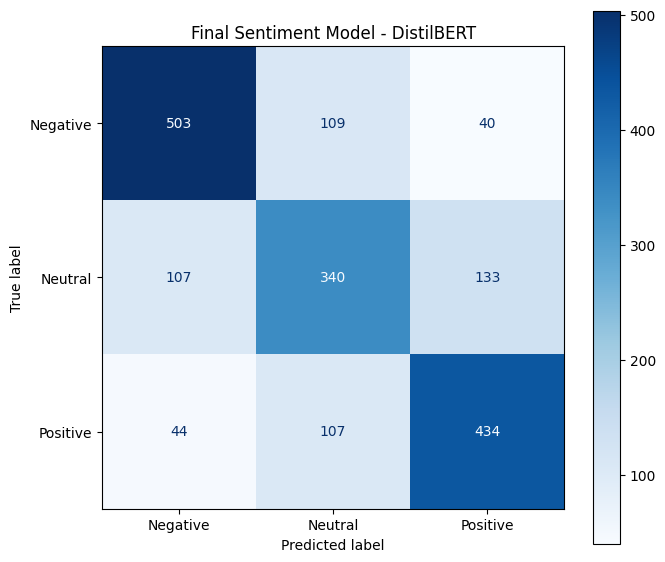

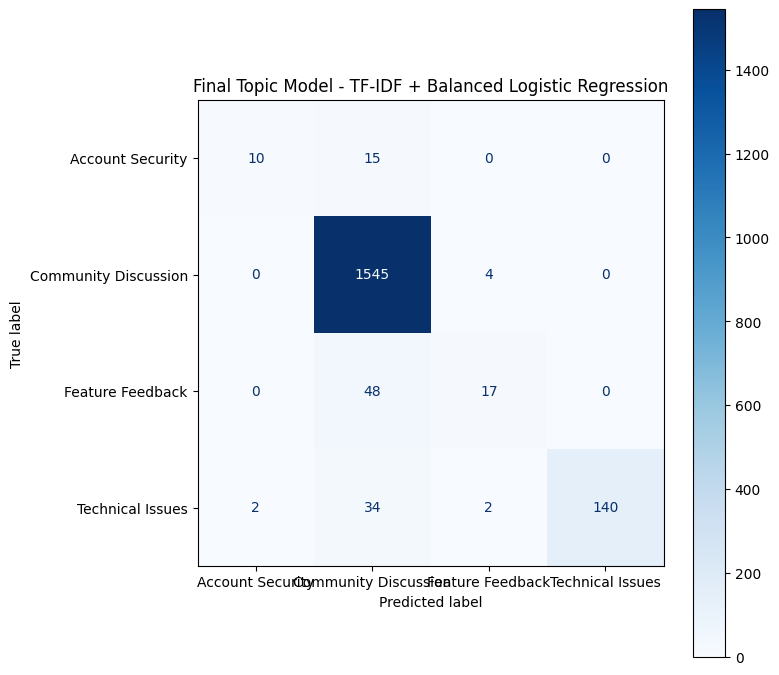

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# ==========================================
# FINAL SENTIMENT CONFUSION MATRIX
# ==========================================

fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    test_sentiment_labels,
    distilbert_sent_pred,
    display_labels=["Negative", "Neutral", "Positive"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title("Final Sentiment Model - DistilBERT")
plt.tight_layout()
plt.show()


# ==========================================
# FINAL TOPIC CONFUSION MATRIX
# ==========================================

fig, ax = plt.subplots(figsize=(8, 7))

ConfusionMatrixDisplay.from_predictions(
    test_df["topic_category"],
    pred_lr_topic,
    display_labels=[
        "Account Security",
        "Community Discussion",
        "Feature Feedback",
        "Technical Issues"
    ],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title("Final Topic Model - TF-IDF + Balanced Logistic Regression")
plt.tight_layout()
plt.show()

In [37]:
# ==========================================
# FINAL SENTIMENT ERROR ANALYSIS
# ==========================================

final_sentiment_errors = test_df[
    test_df["sentiment_label"] != distilbert_sent_pred
].copy()

final_sentiment_errors["predicted_sentiment"] = (
    distilbert_sent_pred[
        test_df["sentiment_label"] != distilbert_sent_pred
    ]
)

print("=" * 60)
print("FINAL SENTIMENT ERROR ANALYSIS")
print("=" * 60)

print("Total errors:", len(final_sentiment_errors))

print("\nMost common errors:")
print(
    final_sentiment_errors[
        ["sentiment_label", "predicted_sentiment"]
    ].value_counts()
)

print("\nSample errors:")
display(
    final_sentiment_errors[
        ["post_text", "sentiment_label", "predicted_sentiment"]
    ].head(25)
)


# ==========================================
# FINAL TOPIC ERROR ANALYSIS
# ==========================================

final_topic_errors = test_df[
    test_df["topic_category"] != pred_lr_topic
].copy()

final_topic_errors["predicted_topic"] = (
    pred_lr_topic[
        test_df["topic_category"] != pred_lr_topic
    ]
)

print("\n\n" + "=" * 60)
print("FINAL TOPIC ERROR ANALYSIS")
print("=" * 60)

print("Total errors:", len(final_topic_errors))

print("\nMost common errors:")
print(
    final_topic_errors[
        ["topic_category", "predicted_topic"]
    ].value_counts()
)

print("\nSample errors:")
display(
    final_topic_errors[
        ["post_text", "topic_category", "predicted_topic"]
    ].head(30)
)

FINAL SENTIMENT ERROR ANALYSIS
Total errors: 1817

Most common errors:
sentiment_label  predicted_sentiment
Negative         0                      503
Positive         2                      434
Neutral          1                      340
                 2                      133
Negative         1                      109
Positive         1                      107
Neutral          0                      107
Positive         0                       44
Negative         2                       40
Name: count, dtype: int64

Sample errors:


,post_text,sentiment_label,predicted_sentiment
1,Mancity strikers Aguero and Dzeko you better t...,Positive,2
5,@user @user aaaah. Nokia used to make the Best...,Negative,2
10,If you're not planning to watch Sharknado 3 to...,Neutral,0
12,@user If all of the Kpop fans came after 1d pe...,Neutral,1
13,If J.Cole and Kendrick Lamar don't realease so...,Negative,0
14,Lakers vs Heat on Jan. 17th! It\u2019s D Wade\...,Negative,0
22,"""Christians threatened with violence for worsh...",Negative,0
27,Also disturbing is that HICK MORON CLERK has n...,Negative,0
28,9 months from Friday there is going to be anot...,Positive,2
32,The game 1st album 1 song he say he rap like E...,Positive,1




FINAL TOPIC ERROR ANALYSIS
Total errors: 105

Most common errors:
topic_category        predicted_topic     
Feature_Feedback      Community_Discussion    48
Technical_Issues      Community_Discussion    34
Account_Security      Community_Discussion    15
Community_Discussion  Feature_Feedback         4
Technical_Issues      Account_Security         2
                      Feature_Feedback         2
Name: count, dtype: int64

Sample errors:


,post_text,topic_category,predicted_topic
409,@user I may relent and get one myself\u002c bu...,Technical_Issues,Community_Discussion
438,Stick with Libero for live updates from the ga...,Technical_Issues,Community_Discussion
457,We're supposed to believe a pap recognised and...,Technical_Issues,Community_Discussion
584,@user - Just watched the Klitschko fight from ...,Feature_Feedback,Community_Discussion
642,I don't see why justin thinks it's okay to wor...,Feature_Feedback,Community_Discussion
740,"""Rappers make millions while saying the N word...",Technical_Issues,Community_Discussion
758,Chris Alexander's TV meltdown on PnP last Wed....,Technical_Issues,Community_Discussion
760,"""fuck everything, i will go see Paper Towns to...",Feature_Feedback,Community_Discussion
807,Cheaper carbon replaces silicon in solar panel...,Feature_Feedback,Community_Discussion
875,"@user cool! yah, lots of stuff going on that n...",Feature_Feedback,Community_Discussion


In [38]:
# ==========================================
# CORRECTED FINAL SENTIMENT ERROR ANALYSIS
# ==========================================

# Convert numeric predictions back to text labels
sentiment_id_to_label = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

predicted_labels = np.array([
    sentiment_id_to_label[x]
    for x in distilbert_sent_pred
])

# Create a copy with predictions for ALL test rows
sentiment_analysis = test_df.copy()

sentiment_analysis["predicted_sentiment"] = predicted_labels

# Keep only incorrect predictions
final_sentiment_errors = sentiment_analysis[
    sentiment_analysis["sentiment_label"] !=
    sentiment_analysis["predicted_sentiment"]
].copy()

print("=" * 60)
print("FINAL SENTIMENT ERROR ANALYSIS")
print("=" * 60)

print("Total errors:", len(final_sentiment_errors))

print("\nMost common errors:")
print(
    final_sentiment_errors[
        ["sentiment_label", "predicted_sentiment"]
    ].value_counts()
)

print("\nSample errors:")
display(
    final_sentiment_errors[
        ["post_text", "sentiment_label", "predicted_sentiment"]
    ].head(25)
)

FINAL SENTIMENT ERROR ANALYSIS
Total errors: 540

Most common errors:
sentiment_label  predicted_sentiment
Neutral          Positive               133
Negative         Neutral                109
Positive         Neutral                107
Neutral          Negative               107
Positive         Negative                44
Negative         Positive                40
Name: count, dtype: int64

Sample errors:


,post_text,sentiment_label,predicted_sentiment
5,@user @user aaaah. Nokia used to make the Best...,Negative,Positive
10,If you're not planning to watch Sharknado 3 to...,Neutral,Negative
32,The game 1st album 1 song he say he rap like E...,Positive,Neutral
43,"""how he should rejoin his companion, who was a...",Positive,Neutral
50,"""Up to 1000 soldiers sealed off the Andersonst...",Negative,Neutral
62,Got me a BAMA shirt like the 1 Lil Wayne had o...,Neutral,Positive
97,"""In a world where Kanye West is president and ...",Negative,Positive
122,"""Even if Real Madrid were at fault for the De ...",Neutral,Negative
134,"""BREAKING NEWS: Bobby, Chloe-Jasmine &amp; Ste...",Neutral,Negative
136,So I just saw the commercial 4 Michael Jackson...,Neutral,Positive


In [39]:
import os
import pickle
import shutil

# ==========================================
# CREATE MODEL DIRECTORY
# ==========================================

os.makedirs("Round_2_Models", exist_ok=True)


# ==========================================
# 1. SAVE FINAL SENTIMENT DISTILBERT
# ==========================================

sentiment_model_path = "Round_2_Models/sentiment_distilbert"

trainer.model.save_pretrained(sentiment_model_path)
tokenizer.save_pretrained(sentiment_model_path)

print("✓ Sentiment DistilBERT saved")


# ==========================================
# 2. SAVE FINAL TOPIC TF-IDF VECTORIZERS
# ==========================================

with open(
    "Round_2_Models/tfidf_word.pkl",
    "wb"
) as f:
    pickle.dump(word_tfidf, f)

with open(
    "Round_2_Models/tfidf_char.pkl",
    "wb"
) as f:
    pickle.dump(char_tfidf, f)

print("✓ Word TF-IDF saved")
print("✓ Character TF-IDF saved")


# ==========================================
# 3. SAVE FINAL TOPIC CLASSIFIER
# ==========================================

# pred_lr_topic was produced using lr_topic_combined
with open(
    "Round_2_Models/topic_model.pkl",
    "wb"
) as f:
    pickle.dump(lr_topic_combined, f)

print("✓ Topic Logistic Regression saved")


# ==========================================
# 4. SAVE LABEL MAPPINGS
# ==========================================

label_mappings = {
    "sentiment": {
        "Negative": 0,
        "Neutral": 1,
        "Positive": 2
    },
    "topic": {
        "Account_Security": 0,
        "Community_Discussion": 1,
        "Feature_Feedback": 2,
        "Technical_Issues": 3
    }
}

with open(
    "Round_2_Models/label_mappings.pkl",
    "wb"
) as f:
    pickle.dump(label_mappings, f)

print("✓ Label mappings saved")


# ==========================================
# 5. SAVE MODEL INFORMATION
# ==========================================

model_info = {
    "sentiment": {
        "model": "distilbert-base-uncased",
        "task": "3-class sentiment classification",
        "classes": [
            "Negative",
            "Neutral",
            "Positive"
        ],
        "max_length": 64,
        "test_accuracy": 0.7028,
        "test_macro_f1": 0.7001
    },

    "topic": {
        "model": "LogisticRegression",
        "representation": "Word TF-IDF + Character TF-IDF",
        "word_ngram_range": (1, 2),
        "char_ngram_range": (3, 5),
        "class_weight": "balanced",
        "C": 1.0,
        "test_accuracy": 0.9422,
        "test_macro_f1": 0.6939
    }
}

with open(
    "Round_2_Models/model_info.pkl",
    "wb"
) as f:
    pickle.dump(model_info, f)

print("✓ Model information saved")


# ==========================================
# 6. LIST SAVED FILES
# ==========================================

print("\n" + "=" * 50)
print("ROUND 2 MODEL FILES")
print("=" * 50)

for root, dirs, files in os.walk("Round_2_Models"):
    level = root.replace("Round_2_Models", "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Sentiment DistilBERT saved
✓ Word TF-IDF saved
✓ Character TF-IDF saved
✓ Topic Logistic Regression saved
✓ Label mappings saved
✓ Model information saved

ROUND 2 MODEL FILES
Round_2_Models/
    model_info.pkl
    tfidf_word.pkl
    label_mappings.pkl
    topic_model.pkl
    tfidf_char.pkl
    sentiment_distilbert/
        tokenizer.json
        tokenizer_config.json
        config.json
        model.safetensors


In [40]:
import shutil
import os

zip_path = shutil.make_archive(
    "DATA_VORTEX_Round_2_Models",
    "zip",
    "Round_2_Models"
)

print("ZIP created:", zip_path)
print("Size:", round(os.path.getsize(zip_path) / (1024 * 1024), 2), "MB")

ZIP created: /content/DATA_VORTEX_Round_2_Models.zip
Size: 237.65 MB


In [ ]:
import zipfile

with zipfile.ZipFile("DATA_VORTEX_Round_2_Models.zip", "r") as z:
    print("\n".join(z.namelist()))

dhddr


In [ ]:
# ============================================================
# TOPIC OPTIMIZATION — TF-IDF FEATURE SEARCH
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score
from scipy.sparse import hstack
import numpy as np

configs = [
    # word settings, char settings
    ((1,1), (3,5)),
    ((1,2), (3,5)),
    ((1,2), (2,6)),
    ((1,3), (3,5)),
    ((1,3), (2,6)),
]

results = []

for word_ngram, char_ngram in configs:

    print("\n" + "="*70)
    print(f"WORD: {word_ngram} | CHAR: {char_ngram}")
    print("="*70)

    word_vec = TfidfVectorizer(
        lowercase=False,
        ngram_range=word_ngram,
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )

    char_vec = TfidfVectorizer(
        analyzer="char",
        ngram_range=char_ngram,
        min_df=2,
        max_features=40000,
        sublinear_tf=True
    )

    Xtr_word = word_vec.fit_transform(train_text)
    Xte_word = word_vec.transform(test_text)

    Xtr_char = char_vec.fit_transform(train_text)
    Xte_char = char_vec.transform(test_text)

    Xtr = hstack([Xtr_word, Xtr_char])
    Xte = hstack([Xte_word, Xte_char])

    model = LogisticRegression(
        C=1.0,
        class_weight="balanced",
        max_iter=3000,
        random_state=42
    )

    model.fit(
        Xtr,
        train_df["topic_category"]
    )

    pred = model.predict(Xte)

    acc = accuracy_score(
        test_df["topic_category"],
        pred
    )

    macro_f1 = f1_score(
        test_df["topic_category"],
        pred,
        average="macro"
    )

    results.append([
        word_ngram,
        char_ngram,
        Xtr.shape[1],
        acc,
        macro_f1
    ])

    print("Features :", Xtr.shape[1])
    print("Accuracy :", round(acc, 4))
    print("Macro F1 :", round(macro_f1, 4))


print("\n\nFINAL COMPARISON")
print("="*70)

for r in sorted(results, key=lambda x: x[4], reverse=True):
    print(
        f"Word={r[0]} | Char={r[1]} | "
        f"Features={r[2]:,} | "
        f"Accuracy={r[3]:.4f} | "
        f"Macro F1={r[4]:.4f}"
    )

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# Best configuration
best_word_vec = TfidfVectorizer(
    lowercase=False,
    ngram_range=(1,1),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

best_char_vec = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3,5),
    min_df=2,
    max_features=40000,
    sublinear_tf=True
)

X_train_word_best = best_word_vec.fit_transform(train_text)
X_test_word_best = best_word_vec.transform(test_text)

X_train_char_best = best_char_vec.fit_transform(train_text)
X_test_char_best = best_char_vec.transform(test_text)

X_train_best = hstack([
    X_train_word_best,
    X_train_char_best
])

X_test_best = hstack([
    X_test_word_best,
    X_test_char_best
])

best_topic_model = LogisticRegression(
    C=1.0,
    class_weight="balanced",
    max_iter=3000,
    random_state=42
)

best_topic_model.fit(
    X_train_best,
    train_df["topic_category"]
)

best_topic_pred = best_topic_model.predict(X_test_best)

print("CLASSIFICATION REPORT")
print("="*70)

print(
    classification_report(
        test_df["topic_category"],
        best_topic_pred,
        digits=4
    )
)

print("\nCONFUSION MATRIX")
print("="*70)

labels = [
    "Account_Security",
    "Community_Discussion",
    "Feature_Feedback",
    "Technical_Issues"
]

cm = confusion_matrix(
    test_df["topic_category"],
    best_topic_pred,
    labels=labels
)

print(pd.DataFrame(
    cm,
    index=["Actual: "+x for x in labels],
    columns=["Pred: "+x for x in labels]
))

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd

# Use the BEST representation found so far:
# Word TF-IDF (1,1) + Character TF-IDF (3,5)

# We already have X_train_best and y_train
y_train_topic = train_df["topic_category"].values

skf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Candidate settings
C_values = [0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0]

weight_sets = [
    {
        "Account_Security": 1.0,
        "Community_Discussion": 1.0,
        "Feature_Feedback": 1.0,
        "Technical_Issues": 1.0
    },
    {
        "Account_Security": 2.0,
        "Community_Discussion": 1.0,
        "Feature_Feedback": 2.0,
        "Technical_Issues": 1.0
    },
    {
        "Account_Security": 3.0,
        "Community_Discussion": 1.0,
        "Feature_Feedback": 3.0,
        "Technical_Issues": 1.5
    },
    {
        "Account_Security": 4.0,
        "Community_Discussion": 1.0,
        "Feature_Feedback": 4.0,
        "Technical_Issues": 1.5
    },
    {
        "Account_Security": 5.0,
        "Community_Discussion": 1.0,
        "Feature_Feedback": 5.0,
        "Technical_Issues": 2.0
    },
    {
        "Account_Security": 2.0,
        "Community_Discussion": 1.0,
        "Feature_Feedback": 3.0,
        "Technical_Issues": 1.5
    },
    {
        "Account_Security": 3.0,
        "Community_Discussion": 1.0,
        "Feature_Feedback": 5.0,
        "Technical_Issues": 1.5
    },
    {
        "Account_Security": 4.0,
        "Community_Discussion": 1.0,
        "Feature_Feedback": 6.0,
        "Technical_Issues": 2.0
    }
]

results = []

for C in C_values:

    for weights in weight_sets:

        fold_scores = []

        for train_idx, val_idx in skf.split(
            X_train_best,
            y_train_topic
        ):

            X_tr = X_train_best[train_idx]
            X_val = X_train_best[val_idx]

            y_tr = y_train_topic[train_idx]
            y_val = y_train_topic[val_idx]

            model = LogisticRegression(
                C=C,
                class_weight=weights,
                max_iter=3000,
                random_state=42
            )

            model.fit(X_tr, y_tr)

            pred = model.predict(X_val)

            score = f1_score(
                y_val,
                pred,
                average="macro"
            )

            fold_scores.append(score)

        results.append({
            "C": C,
            "weights": str(weights),
            "CV_Macro_F1": np.mean(fold_scores)
        })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "CV_Macro_F1",
    ascending=False
)

print("TOP 15 CONFIGURATIONS")
print("=" * 100)

print(
    results_df.head(15).to_string(index=False)
)